In [1]:
import numpy as np
import pandas as pd
import random
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sc
import math
from scipy import stats 
from scipy.optimize import minimize
import statsmodels.formula.api as smf
import statsmodels.api as sm

In [2]:
np.random.seed(42)
random.seed(42)
rng = np.random.default_rng(seed=42)
plt.style.use('ggplot')
sns.set_theme(style="darkgrid")

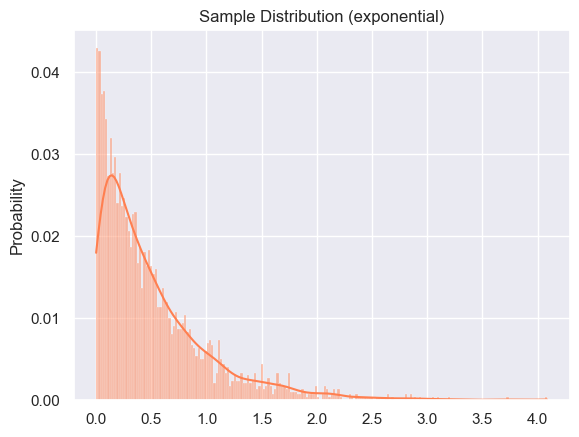

In [3]:
d_lambda = 2
sample = np.random.exponential(1/d_lambda, 3000)
plt.title("Sample Distribution (exponential)")
sns.histplot(sample, bins=200, stat='probability', kde=True, color='coral')
plt.show()

bootstrap is an asymptotical method that allows us to find distribution of any statistic from sample

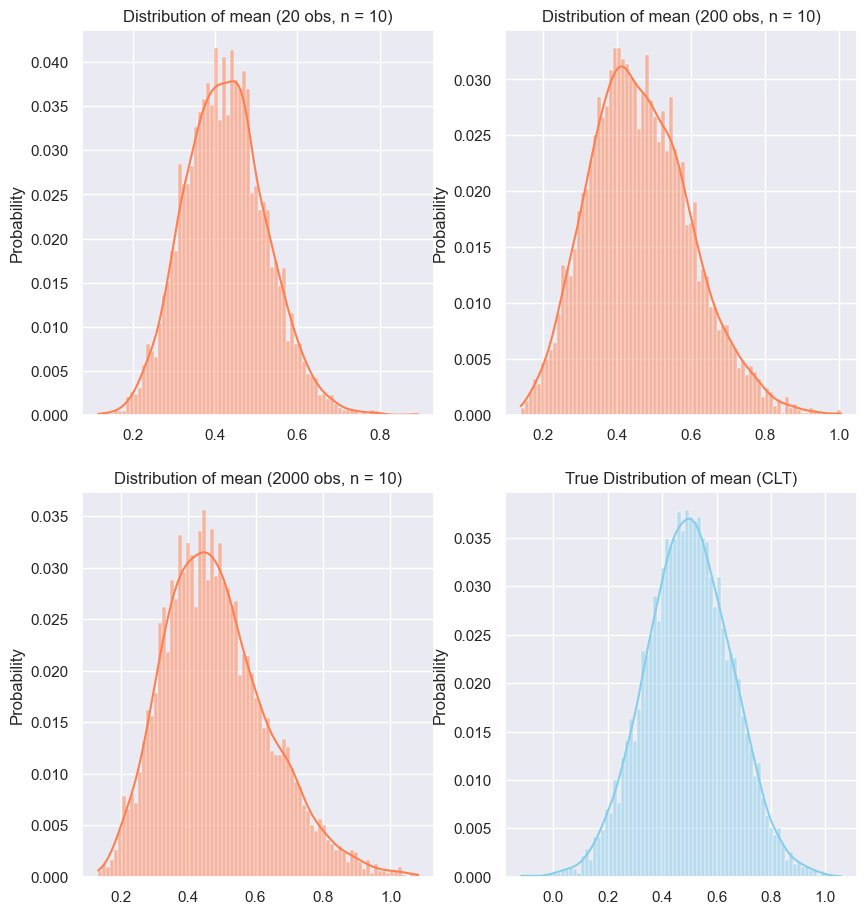

In [4]:
#Visual
fig, ax = plt.subplots(2, 2, figsize=(10, 11))

all_means = []
for i in range(2):
    for j in range(2):
        #Space for true distribution
        if i + j == 2:
            break

        #Sample size
        pw = 10 ** (i * 2 + j)
        sample_buf = np.random.exponential(1/d_lambda, 20 * pw)
        ax[i, j].set_title(f"Distribution of mean ({20*pw} obs, n = 10)")

        #Choose 5000 subsamples with size 10
        means = rng.choice(sample_buf, size=(5000, 10), replace=True)
        means = means.mean(axis=1)
        sns.histplot(means, bins=80, stat='probability', kde=True, color='coral', ax=ax[i, j])

        #Save means for later :)
        all_means.append(means)

#True distribution of mean
true_dist = np.random.normal(loc=1/d_lambda, scale=np.sqrt(1/(d_lambda**2)/10), size=7000)
sns.histplot(true_dist, bins=80, stat='probability', kde=True, color='skyblue', ax=ax[i, j])
ax[1, 1].set_title("True Distribution of mean (CLT)")
plt.show()

Let's check which approximation fits the normal curve best. 

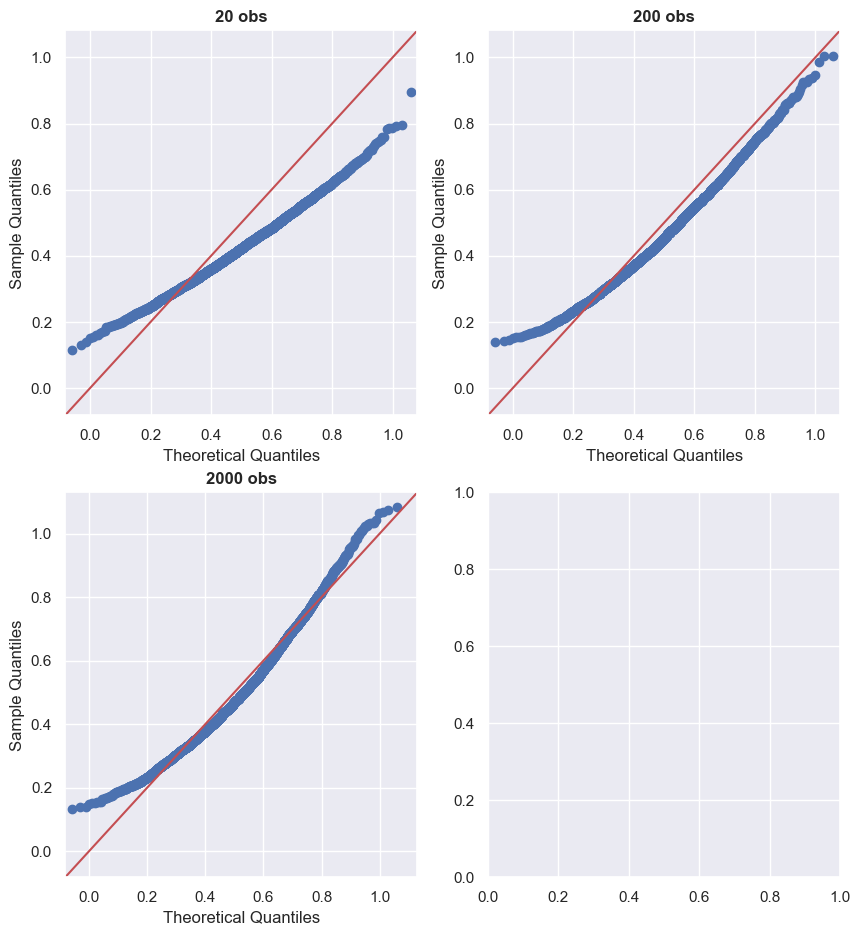

In [5]:
#Visual
all_means = np.array(all_means)
fig, ax = plt.subplots(2, 2, figsize=(10, 11))

#Parameters
loc = 1 / d_lambda
scale = np.sqrt(1/(d_lambda ** 2)/10)

for i in range(2):
    for j in range(2):
        if i + j == 2:
            break
        pw = 10 ** (i * 2 + j)
        sm.qqplot(all_means[i * 2 + j], line='45', loc=loc, scale=scale, ax=ax[i, j])
        ax[i, j].set_title(f"{20 * pw} obs", fontweight='bold')
plt.show()

More observations usually lead to more accurate result :)

Instead of subsampling we can generate frequencies from Poisson distribution with parameter 1

In [6]:
#Sample procedure
sample_p = np.array([2, 2, 4, 4, 7, 5, 5, 5])

#Unique values
u = np.unique(sample_p)

#Frequencies
freq = np.random.poisson(lam=1, size=4)
print("Frequencies:", freq)

#Generating sample
print("Sample:", [ [i[1]] * freq[i[0]] for i in enumerate(u)] )

Frequencies: [2 3 3 0]
Sample: [[2, 2], [4, 4, 4], [5, 5, 5], []]


Making assumptions about statistics is also possible. Let's try to estimate 0.95 percentile for mean (size = 10)

In [7]:
n = 10
sample = np.random.exponential(1/d_lambda, 50) #Exp0nential

In [8]:
sample = rng.choice(sample, size=(5000, n), replace=True)
sample_se = np.sqrt(sample.var(ddof=1,axis=1)/n)
sample_mu = sample.mean(axis=1)

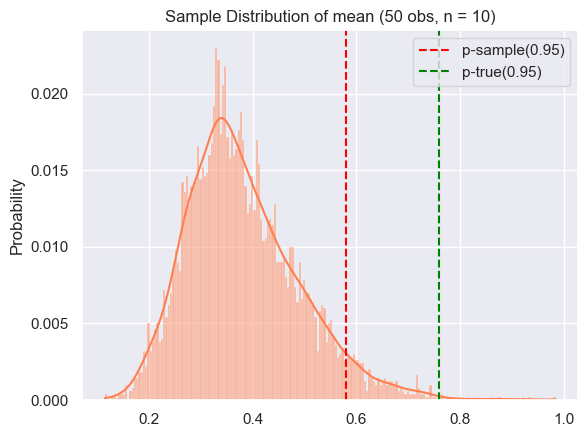

In [9]:
plt.title("Sample Distribution of mean (50 obs, n = 10)")
sns.histplot(sample_mu, bins=200, stat='probability', kde=True, color='coral')
plt.axvline(x=np.quantile(sample_mu, q=0.95), color='red', linestyle='--', label="p-sample(0.95)")
plt.axvline(x=stats.norm(loc=loc, scale=scale).ppf(0.95), color='green', linestyle='--', label="p-true(0.95)")
plt.legend()
plt.show()

Our distribution is skewed to the left so convergence rate is small :(

We can use a different method of estimation to improve accuracy :) (Bootstrap-t)

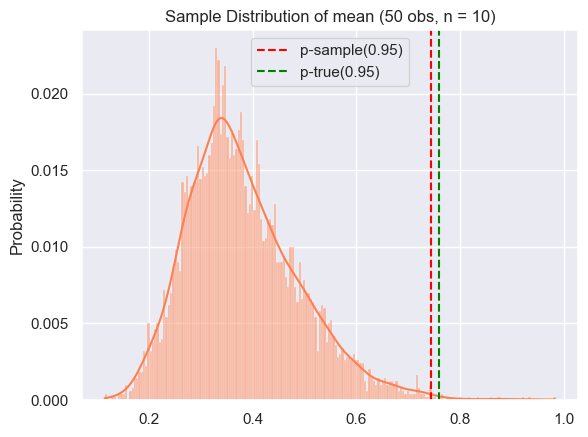

In [10]:
#Parameters
mu = sample_mu.mean()
se = np.sqrt(sample_mu.var(ddof=1))

#Normalization
sample_norm = (sample_mu - sample.mean()) / sample_se
origin_se = np.sqrt(sample.var(ddof=1)/10)

#Graph skewed to the right, so inversed CI will perform better
t_crit = mu - np.quantile(sample_norm, q=0.05/2) * origin_se
#If graph is skewed to the left just take 0.95 quantile from normalized data

plt.title("Sample Distribution of mean (50 obs, n = 10)")
sns.histplot(sample_mu, bins=200, stat='probability', kde=True, color='coral')
plt.axvline(x=t_crit, color='red', linestyle='--', label="p-sample(0.95)")
plt.axvline(x=stats.norm(loc=loc, scale=scale).ppf(0.95), color='green', linestyle='--', label="p-true(0.95)")
plt.legend()
plt.show()


$$ q_L \le \widehat{\theta} - \theta \le q_R $$
$$ -q_R \le \widehat{\theta} - \theta \le -q_L $$
$$ \widehat{\theta} - q_R \le \theta \le\widehat{\theta} - q_L $$
If distribution is skewed to the right, this interval will produce an accurate right border

If skewed to the left, np.quantile(0.95) should perform better

We can mix these 2 methods to produce an accurate CI (significance level = alpha/2 for each), but it will be assymetrical and not the shortest

In t-bootstrap we can estimate SE of subsample via another bootstrap

In [11]:
d_lambda = 2
sample = np.random.exponential(1/d_lambda, 300)

In this case the function will estimate some percentile for sample at alpha=0.05

In [12]:
def t_bootstrap(sample, q, alpha=0.05):
    #Bootstrap
    b1 = rng.choice(sample, size=(3000, 175), replace=True)
    #Sample quantile
    p = np.quantile(sample, q=q)
    #Bootstraping SE for each subsample
    boot_se = []
    #Try to make it without for :)
    for i in b1:
        boot_p = rng.choice(i, size=(100, 15), replace=True)
        boot_p = np.quantile(boot_p, q=q, axis=1)
        boot_se.append(np.std(boot_p, ddof=1))
    boot_se = np.array(boot_se)
    
    boot_t = np.quantile(b1, q=q, axis=1)
    se = np.std(boot_t, ddof=1)

    boot_t = (boot_t - p) / boot_se

    #Only right border
    return np.quantile(boot_t, q=1-alpha) * se + p

    #return p - np.quantile(boot_t, q=alpha/2) * se

0.5344879461966787


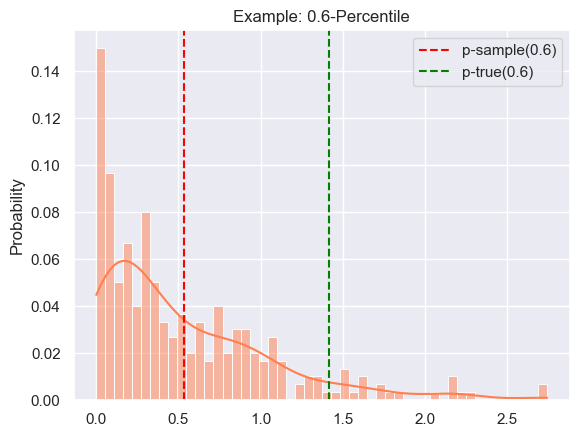

In [13]:
q = 0.6
t_crit = t_bootstrap(sample, q=q)
print(t_crit)
plt.title(f"Example: {q}-Percentile")
sns.histplot(sample, bins=50, stat='probability', kde=True, color='coral')
plt.axvline(x=t_crit, color='red', linestyle='--', label=f"p-sample({q})")
plt.axvline(x=stats.expon(1/d_lambda).ppf(q=q), color='green', linestyle='--', label=f"p-true({q})")
plt.legend()
plt.show()

Since the distribution is skewed to the right, the bootstrap greatly underestimates the value.

In [14]:
#Scipy bootstrap
result = stats.bootstrap(
    (sample,), 
    method='bca',
    statistic=lambda x, axis: np.quantile(x, q=0.6, axis=axis),
    alternative='less',
    confidence_level=0.95,
    n_resamples=12000,
    random_state = 42
    )
print(result.confidence_interval.high)

0.5845270432717038


Let's put everything together in one picture

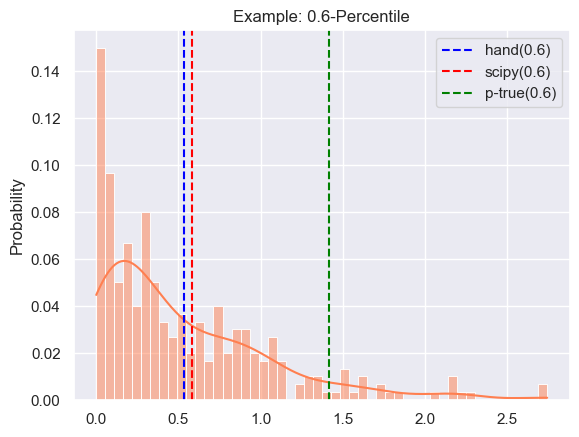

In [15]:
q = 0.6
t_crit = t_bootstrap(sample, q=q)
plt.title(f"Example: {q}-Percentile")
sns.histplot(sample, bins=50, stat='probability', kde=True, color='coral')
plt.axvline(x=t_crit, color='blue', linestyle='--', label=f"hand({q})")
plt.axvline(x=result.confidence_interval.high, color='red', linestyle='--', label=f"scipy({q})")
plt.axvline(x=stats.expon(1/d_lambda).ppf(q=q), color='green', linestyle='--', label=f"p-true({q})")
plt.legend()
plt.show()